# Notebook 3 — Contract-Level Risk Classification

**Goal:** Score each lease contract by its residual value risk.  
Segment the risk by fuel type, age band, and brand.  
Produce the risk heatmap that goes in your portfolio.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_palette('muted')

df = pd.read_csv('../data/vehicles_with_predictions.csv')
print(f'Loaded: {len(df):,} rows')

Loaded: 471,338 rows


## 1. Risk Score per Contract

In [2]:
# ── Guaranteed RV = 50% of estimated new price ────────────────────────────────
# Re-derive if not already in predictions file
if 'guaranteed_rv' not in df.columns:
    def estimate_new_price(row):
        age = max(row['vehicle_age'], 0)
        factor = 0.85 * (0.90 ** (age - 1)) if age >= 1 else 1.0
        return row['price_actual'] / factor
    df['estimated_new_price'] = df.apply(estimate_new_price, axis=1)
    df['guaranteed_rv']       = df['estimated_new_price'] * 0.50

# ── Risk metrics ──────────────────────────────────────────────────────────────
# Use MODEL PREDICTION as the expected end-of-lease market value
df['expected_market_rv'] = df['price_pred']
df['rv_gap']             = df['expected_market_rv'] - df['guaranteed_rv']  # negative = at risk
df['at_risk']            = (df['rv_gap'] < 0).astype(int)
df['risk_exposure']      = np.maximum(-df['rv_gap'], 0)

# ── Risk tier ─────────────────────────────────────────────────────────────────
def risk_tier(row):
    if row['at_risk'] == 0:
        return 'Low'
    elif row['risk_exposure'] < 2_000:
        return 'Medium'
    elif row['risk_exposure'] < 5_000:
        return 'High'
    else:
        return 'Critical'

df['risk_tier'] = df.apply(risk_tier, axis=1)

print('=== Risk Tier Distribution ===')
print(df['risk_tier'].value_counts())
print(f'\nTotal portfolio exposure: €{df["risk_exposure"].sum():,.0f}')

=== Risk Tier Distribution ===
Critical    377920
High         52317
Low          20696
Medium       20405
Name: risk_tier, dtype: int64

Total portfolio exposure: €7,077,027,116


## 2. Risk Heatmap by Age Band & Fuel Type

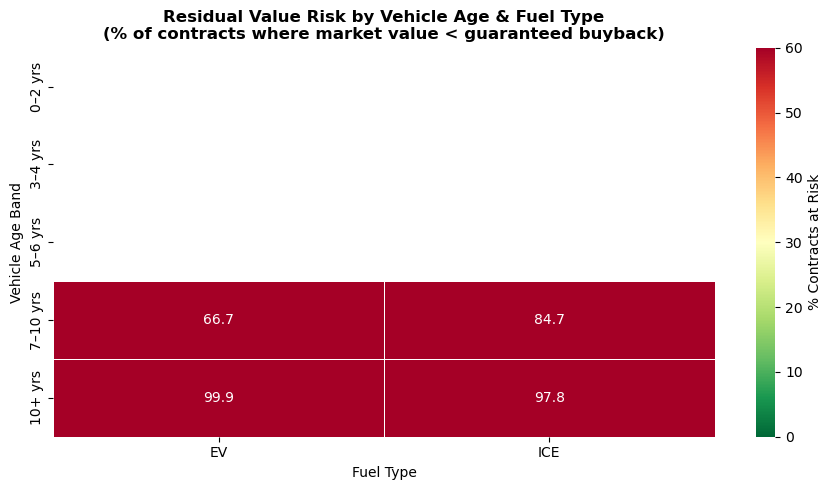

💾 Saved: outputs/06_risk_heatmap.png


In [3]:
# ── Age bands ─────────────────────────────────────────────────────────────────
df['age_band'] = pd.cut(
    df['vehicle_age'],
    bins=[0, 2, 4, 6, 10, 20],
    labels=['0–2 yrs', '3–4 yrs', '5–6 yrs', '7–10 yrs', '10+ yrs']
)
df['fuel_label'] = df['is_ev'].map({1: 'EV', 0: 'ICE'})

# ── Heatmap: % at risk ────────────────────────────────────────────────────────
heatmap_data = df.groupby(['age_band', 'fuel_label'])['at_risk'].mean().unstack() * 100

plt.figure(figsize=(9, 5))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.1f', cmap='RdYlGn_r',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': '% Contracts at Risk'},
    vmin=0, vmax=60
)
plt.title('Residual Value Risk by Vehicle Age & Fuel Type\n(% of contracts where market value < guaranteed buyback)',
          fontweight='bold', fontsize=12)
plt.xlabel('Fuel Type')
plt.ylabel('Vehicle Age Band')
plt.tight_layout()
plt.savefig('../outputs/06_risk_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: outputs/06_risk_heatmap.png')

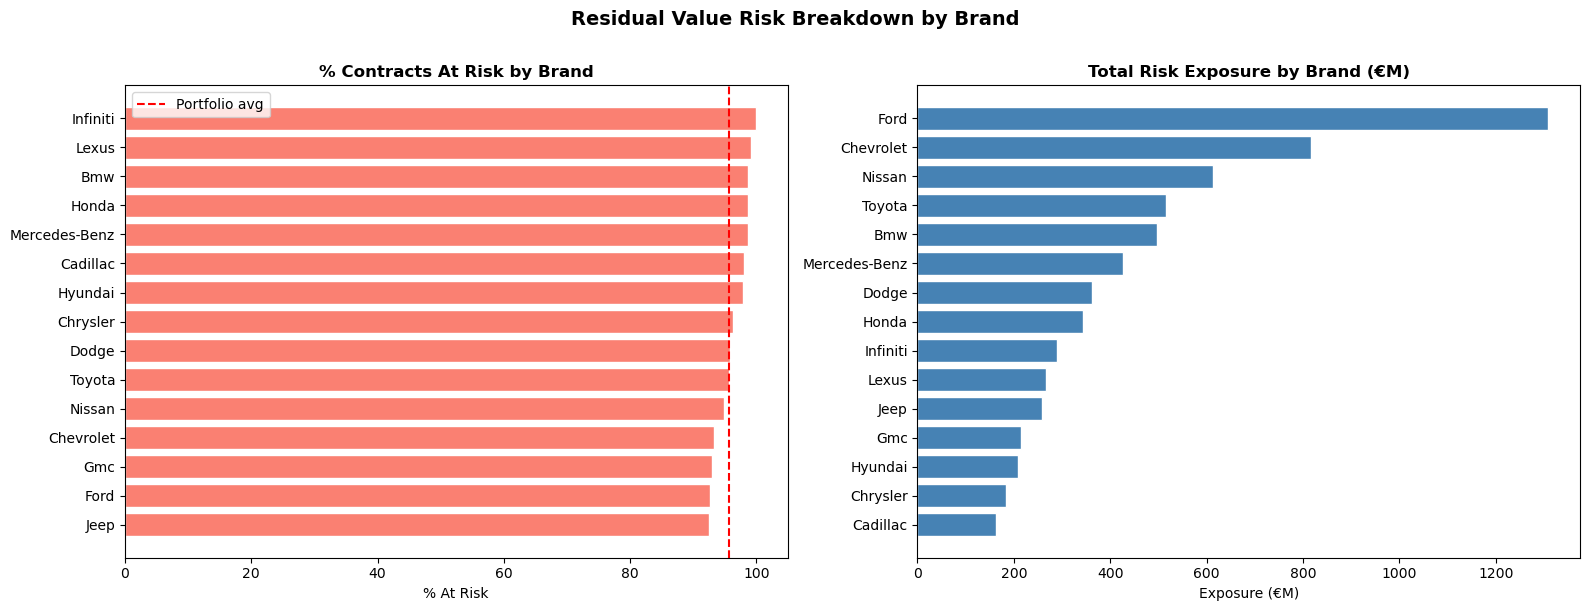

💾 Saved: outputs/07_risk_by_brand.png


In [4]:
# ── Risk exposure by brand (if available) ─────────────────────────────────────
if 'brand' in df.columns:
    brand_risk = (
        df.groupby('brand')
        .agg(
            contracts=('at_risk', 'count'),
            pct_at_risk=('at_risk', 'mean'),
            total_exposure=('risk_exposure', 'sum'),
            avg_exposure=('risk_exposure', 'mean')
        )
        .query('contracts >= 50')  # enough data
        .sort_values('total_exposure', ascending=False)
        .head(15)
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # % at risk
    brand_risk_sorted = brand_risk.sort_values('pct_at_risk', ascending=True)
    axes[0].barh(brand_risk_sorted.index, brand_risk_sorted['pct_at_risk'] * 100,
                 color='salmon', edgecolor='white')
    axes[0].set_title('% Contracts At Risk by Brand', fontweight='bold')
    axes[0].set_xlabel('% At Risk')
    axes[0].axvline(x=df['at_risk'].mean() * 100, color='red', 
                    linestyle='--', label='Portfolio avg')
    axes[0].legend()

    # Total exposure
    brand_risk_sorted2 = brand_risk.sort_values('total_exposure', ascending=True)
    axes[1].barh(brand_risk_sorted2.index, brand_risk_sorted2['total_exposure'] / 1e6,
                 color='steelblue', edgecolor='white')
    axes[1].set_title('Total Risk Exposure by Brand (€M)', fontweight='bold')
    axes[1].set_xlabel('Exposure (€M)')

    plt.suptitle('Residual Value Risk Breakdown by Brand', fontweight='bold', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig('../outputs/07_risk_by_brand.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('💾 Saved: outputs/07_risk_by_brand.png')

In [5]:
# ── Save risk-scored data ─────────────────────────────────────────────────────
df.to_csv('../data/vehicles_risk_scored.csv', index=False)
print('✅ Saved: data/vehicles_risk_scored.csv')
print('\n→ Next: open 04_monte_carlo.ipynb')

✅ Saved: data/vehicles_risk_scored.csv

→ Next: open 04_monte_carlo.ipynb
